# Foundations of Machine learning

Problem Set 4

Emily Fu

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys  
import os
from pathlib import Path

# importing my code from another file
import importlib
sys.path.insert(0, str(Path.cwd()))

import functions_A4
from functions_A4 import bernoulli_bandit_thompson, calculate_replication, evaluate_bandit

# set seed
seed = 420

In this problem, you are asked to simulate data for a Bernoulli bandit problem, where $D_t \in \{1,...,k\}$, $Yt = Y^{D}_t$ , $Y^{d}_t ∼ \text{Ber}( \theta_{d} )$ and treatment is assigned using Thompson sampling with a uniform prior, $(\theta_{1},...,\theta_{k}) ∼ U([0,1]^k)$. Recall that Thompson sampling assigns $D_t = \text{argmax}_d \: \hat{\theta}^{d}_t$, where $\hat{\theta}_t$ is a draw from the posterior after period $t−1$.

Set up a function which accepts a sample size $T$ and a k-vector $(\theta_{1},...,\theta_{k})$ as its arguments, and returns a history $(D_t,Y_t)^T_{t=1}$ generated based on the Bernoulli bandit model and Thompson sampling

I'm writing this in the VSCode Jupyter extension and can't get parallel computing to work in its actual UI, so I've made up a Python file for all my functions and am pasting the below here as plaintext:

```
def bernoulli_bandit_thompson(T, theta, seed=420):
    rng = np.random.default_rng(seed)

    # get the amount of treatments from their true expected outcomes
    k = len(theta)
    
    # initialise arrays to store the selected treatments and observed outcomes
    D_t = np.zeros(T, dtype=int)
    Y_t = np.zeros(T)
    
    # the posterior for theta_d at time t + 1 is a Beta distribution with parameters
    # start with uniform prior over theta on [0, 1]^k
    # 1 + number of successes
    alpha = np.ones(k)
    # 1 + number of failures
    beta = np.ones(k)
    
    for t in range(T):
        # sample from the Beta distribution for each arm
        samples = rng.beta(alpha, beta)
        # print(samples)
        
        # find which treatment gave the highest sample and select that treatment
        action = np.argmax(samples)
        # store which treatment this corresponds to
        D_t[t] = action
        
        # assume that outcome follows a Bernoulli distribution with parameter theta[action]
        outcome = rng.binomial(1, theta[action])
        Y_t[t] = outcome
        # print(outcome)
        
        # update alpha and beta parameters of posterior based on the observed outcome
        if outcome == 1:
            # another success
            alpha[action] += outcome
        else:
            # not success
            beta[action] += 1 - outcome
            
    return D_t, Y_t
```

Write a second function which takes the same arguments, plus a number of replications $R$, and evaluates the first function $R$ times (using parallel computing; for instance the `future` package). This function should return 4 vectors of length $T$: The averages of $Y_t$, $\theta^{D_t}$, ${1(D_t = \text{argmax}_d \: \theta_{d})}$, and $\text{max} \: \theta_{d} − \theta^{D_t} $, for each time period $t$.

Splitting this into one kind-of-lambda function and one that does the parallel computing (from what I've found, there are multiple parallel computing options for Python and I've used [`dask`](https://docs.dask.org/en/stable/)):

```
def calculate_replication(T, theta, seed=420):
    # format of theta
    theta = np.asarray(theta, dtype=float)

    # get the actions and outcomes for T time steps
    D_t, Y_t = bernoulli_bandit_thompson(T, theta, seed=seed)

    # best treatment and its theta value
    best_arm = np.argmax(theta)
    best_theta = np.max(theta)
    
    # get the theta value of the selected arm at each time step
    theta_Dt = theta[D_t]
    # how many times the optimal treatment was selected at each time step
    optimal_indicator = (D_t == best_arm).astype(float)
    # calculate regret at each time step
    regret_t = best_theta - theta_Dt

    return Y_t.astype(float), theta_Dt, optimal_indicator, regret_t

def evaluate_bandit(T, theta, R, seed=420):
    # format of theta
    theta = np.asarray(theta, dtype=float)

    # actually do it for the R replications
    tasks = [delayed(calculate_replication)(T, theta, seed + r) for r in range(R)]

    # compute the results in parallel using dask
    results = compute(*tasks, scheduler='threads')

    # aggregate results across replications
    Y_all = np.array([res[0] for res in results])
    thetaDt_all = np.array([res[1] for res in results])
    opt_all = np.array([res[2] for res in results])
    regret_all = np.array([res[3] for res in results])

    # averagevalues of Y_t, theta_Dt, optimal indicator, and regret_t across the R replications
    avg_Y_t = Y_all.mean(axis=0)
    avg_theta_Dt = thetaDt_all.mean(axis=0)
    avg_optimal = opt_all.mean(axis=0)
    avg_regret_t = regret_all.mean(axis=0)

    # cumulative average regret and average of cumulative average regret across the R replications
    avg_cum_regret_t = np.cumsum(avg_regret_t)
    avg_cumavg_regret_t = avg_cum_regret_t / np.arange(1, T + 1)

    return avg_Y_t, avg_theta_Dt, avg_optimal, avg_regret_t, avg_cum_regret_t, avg_cumavg_regret_t
```

Pick a fixed vector of parameters $(\theta_{1},...,\theta_{k})$ and a time horizon $T$ and use the second function to plot the average (across replications) of cumulative average regret

$$\frac{1}{T} \sum_{1 \leq t \leq T} [(\text{max}_{d} \: \theta^{d}) - \theta^{D_t}]$$

as a function of T, using a large number of replications $R$ (such as $R = 10.000$). 

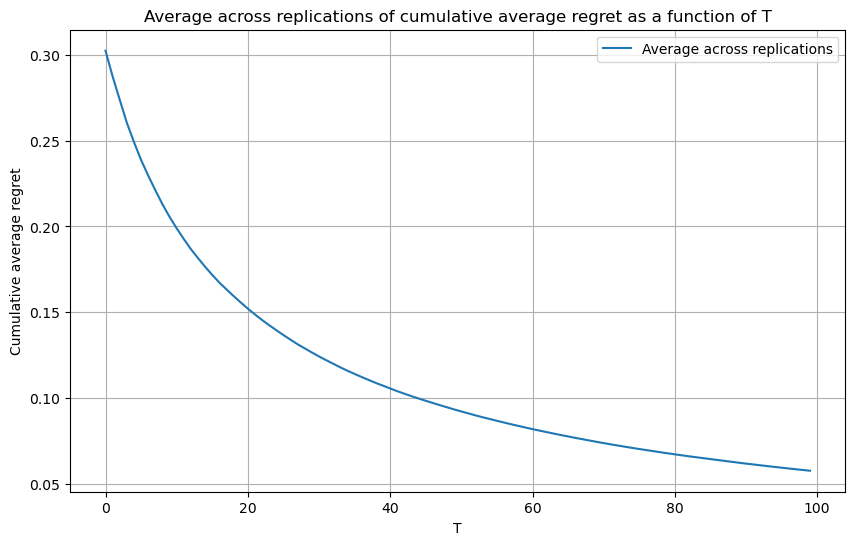

In [3]:
theta = [0.2, 0.5, 0.8]
T = 100
R = 10000

avg_Y_t, avg_theta_Dt, avg_optimal, avg_regret_t, avg_cum_regret_t, avg_cumavg_regret_t = evaluate_bandit(T, theta, 
                                                                                                          R, seed=seed)

# plot average (across replications) of cumulative average regret as a function of T
plt.figure(figsize=(10, 6))
plt.plot(avg_cumavg_regret_t, label='Average across replications')
plt.xlabel('T')
plt.ylabel('Cumulative average regret')
plt.title('Average across replications of cumulative average regret as a function of T')
plt.legend()
plt.grid()
plt.show()


Repeat this for several different choices of $(\theta_{1},...,\theta_{k})$. 

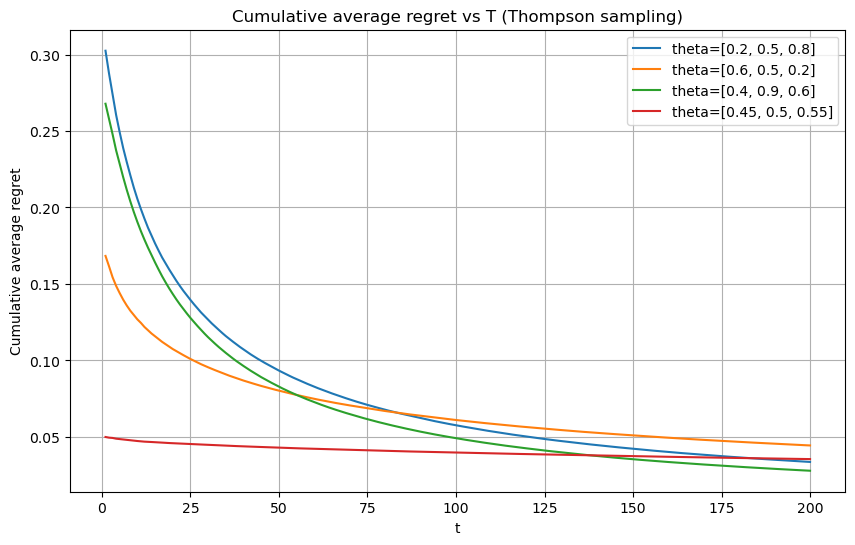

In [6]:
# some thetas
thetas = [[0.2, 0.5, 0.8], [0.6, 0.5, 0.2], [0.4, 0.9, 0.6], [0.45, 0.5, 0.55]]

T = 200
R = 10000

plt.figure(figsize=(10, 6))
x = np.arange(1, T + 1)

# calculate cumulative average regret for all thetas and plot them on the same graph
for i, theta in enumerate(thetas):
    avg_cumavg_regret_t = evaluate_bandit(T, theta, R, seed=seed + 10_000 * i)[-1]
    plt.plot(x, avg_cumavg_regret_t, label=f'theta={theta}')

plt.xlabel('t')
plt.ylabel('Cumulative average regret')
plt.title('Cumulative average regret vs T (Thompson sampling)')
plt.legend()
plt.grid(True)
plt.show()

How does the result relate to the theoretical regret rate bound discussed in class, and to Agrawal and Goyal (2012)?

The result from the slides says that expected regret (difference to optimal policy) goes to 0 at a rate of $\text{O}(\log(T)/T)$ for the UCB algorithm. For large $T$, similar upper bounds on $\mathop{\mathbb{E}}[T_{d}^{T}]$ (the amount of times the treatment is used) for the UCB algorithm hold for Thompson sampling. Then, Theorem 2 from Agrawal and Goyal (2012) shows that the
Thompson Sampling algorithm also has logarithmic

for the N-armed stochastic bandit problem: the Thompson sampling algorithm has expected regret

$$\mathop{\mathbb{E}}[R(T)] \leq \text{O} ((\sum_{a = 2}^{N} \frac{1}{\Delta^{2}_{a}})^2 (\ln T))$$

They're using $a$ to denote each treatment out of $N$ total treatments, and $\mathop{\mathbb{E}}[R(T)]$ would be expected cumulative regret. This means they showed that cumulative regret grows logarithmically in time, so if I divide by $T$, I get the same $\text{O}(\log(T)/T)$ rate for Thompson Sampling.

Here, the thing I'm plotting is cumulative regret divided by time across all my replications, which is the sample version of how expected regret $R_T$ is defined in the slides and it is decreasing in $T$ close to zero, but decreases slower with higher $T$. The point of this is that as you get more history, you learn with the Thompson sampling algorithm which treatment is more likely to succeed. Then, cumulative regret grows slowly and its average will go to zero. Every time we were observing our outcome and updating the posterior, we were increasing the parameters in the beta distribution so that the more successful treatments are more likely to be chosen again which makes average regret decrease. However, once the regret is already small and the probability that Thompson sampling picks the wrong treatment becomes very small, cumulative average regret will decrease by less. I chose a few $\theta$ s with different expected outcomes, and the ones with treatments that vary in expected outcome by a lot have higher average regret as T is small but that decay faster. One of my choices was $\theta = [0.45, 0.5, 0.55]$, which is much flatter than the others since the expeced outcomes are close to each other and so regret is always small and I think it wouldn't learn which one is the best treatment as fast.

Now let $k = 2$, fix $\theta_{1} = 0.5$ and $T = 200$. Plot cumulative average regret for $T$ as a function of $\theta_{2}$, for $\theta_{2} \in [0,1]$. Do the same for the share of observations assigned to the optimal treatment.

How does the result relate to the local-to-zero asymptotics discussed in class, and to Figure 3 in Wager and Xu (2021)?